# 신용카드 채무불이행 고객 예측 -

https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset

In [87]:
# !pip install xlrd --break-system-packages


In [88]:
import pandas as pd
import urllib.request
import os

os.makedirs('./data', exist_ok=True)

# UCI 원본
# url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00350/default%20of%20credit%20card%20clients.xls"
# urllib.request.urlretrieve(url, './data/UCI_Credit_Card.xls')

# xls 읽기
df = pd.read_excel('./data/UCI_Credit_Card.xls', header=1)
df.to_csv('./data/UCI_Credit_Card.csv', index=False)
print(df.shape)

# df = pd.read_csv('./data/UCI_Credit_Card.csv')
card_df = df.drop('ID', axis=1)
card_df.head(3)

(30000, 25)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0


In [89]:
card_df = card_df.rename(columns={'default payment next month': 'default'})

y_target = card_df['default']
X_features = card_df.drop('default', axis=1)


# 모델링 프로세스 요약**

**Target** : `default` (0 = 정상, 1 = 채무불이행)

**1단계 EDA**
- 타깃 클래스 비율 확인 (불균형 여부)
- 결측치 · 이상치 탐색
- 주요 피처 분포 및 타깃과의 상관관계 시각화

**2단계 데이터 전처리**
- 범주형 피처 인코딩 (필요 시)
- 수치형 피처 스케일링 (StandardScaler 등)
- 불필요 컬럼 제거

**3단계 Train / Test Split**
- `train_test_split` — `stratify=y` 옵션으로 클래스 비율 유지
- 일반적으로 80 : 20 분할

**4단계 모델 학습**
- Logistic Regression 
- Random Forest (베이스라인)
- XGBoost

**5단계 모델 평가**
- Accuracy, Precision, Recall, F1-Score
- ROC-AUC Curve — 불균형 데이터에서 특히 중요

**6단계 피처 중요도**
- 트리 기반 모델의 feature importance 시각화
- 예측에 영향을 주는 핵심 변수 파악

**7단계 하이퍼파라미터 튜닝 (선택)**
- GridSearchCV 또는 RandomizedSearchCV
- 최적 파라미터로 최종 모델 재학습

**EDA**

In [90]:
# 타깃 클래스 비율 확인
print("=== 타깃 클래스 분포 ===")
print(y_target.value_counts())
print()
print(f"정상(0)     : {y_target.value_counts()[0]:,}명  ({y_target.value_counts(normalize=True)[0]:.1%})")
print(f"채무불이행(1): {y_target.value_counts()[1]:,}명  ({y_target.value_counts(normalize=True)[1]:.1%})")


=== 타깃 클래스 분포 ===
default
0    23364
1     6636
Name: count, dtype: int64

정상(0)     : 23,364명  (77.9%)
채무불이행(1): 6,636명  (22.1%)


In [91]:
# 타깃 클래스 비율 확인
print("=== 타깃 클래스 분포 ===")
print(y_target.value_counts())
print()
print(f"정상(0)     : {y_target.value_counts()[0]:,}명  ({y_target.value_counts(normalize=True)[0]:.1%})")
print(f"채무불이행(1): {y_target.value_counts()[1]:,}명  ({y_target.value_counts(normalize=True)[1]:.1%})")


=== 타깃 클래스 분포 ===
default
0    23364
1     6636
Name: count, dtype: int64

정상(0)     : 23,364명  (77.9%)
채무불이행(1): 6,636명  (22.1%)


**분석 결과**

- 정상(0) : 23,364명 (77.9%)
- 채무불이행(1) : 6,636명 (22.1%)
- 비율 약 4 : 1 → 클래스 불균형(Class Imbalance) 존재

**모델링 시 주의사항**

- Accuracy 만으로는 평가 불충분 → 모델이 전부 0으로 예측해도 77.9% 달성 가능
- Recall, F1-Score, ROC-AUC 를 주요 평가 지표로 사용
- 채무불이행(소수 클래스)을 놓치는 것이 비즈니스 손실이 크므로 Recall 이 특히 중요
- 필요 시 `class_weight='balanced'` 또는 오버샘플링(SMOTE) 적용 고려

In [92]:
# 결측치 확인
print("=== 결측치 확인 ===")
print(X_features.isnull().sum())
print(f"\n총 결측치 수 : {X_features.isnull().sum().sum()}")


=== 결측치 확인 ===
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
dtype: int64

총 결측치 수 : 0


**분석 결과** : 결측치 없음 → 별도 결측치 처리 불필요

In [93]:
# 기술통계 확인
print("=== 기술통계 ===")
X_features.describe()


=== 기술통계 ===


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000
mean,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,-0.266200,...,4.701315e+04,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567
std,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,1.133187,...,6.934939e+04,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775
min,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000
25%,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2.666250e+03,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000
50%,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,2.008850e+04,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000
75%,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,6.016475e+04,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000
max,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,8.000000,...,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000


# 기술통계 분석 결과**

**이상값 (전처리 필요)**
- `EDUCATION` : 정의된 값은 1~4 (1=대학원, 2=대학, 3=고등학교, 4=기타) → min=0, max=6 으로 **0, 5, 6 은 미정의값** → 4(기타)로 통합 필요
- `MARRIAGE` : 정의된 값은 1~3 (1=기혼, 2=미혼, 3=기타) → min=0 으로 **0 은 미정의값** → 3(기타)으로 통합 필요
- `BILL_AMT` : 음수값 존재 (과납으로 인한 크레딧 잔액) → 이상치 아님, 그대로 유지

**정상 범위 확인**
- `PAY_0 ~ PAY_6` : -2(소비없음), -1(정상납부), 0(리볼빙), 1~8(연체 개월수) → 음수값은 정상
- `AGE` : 21 ~ 79세 → 정상 범위
- `PAY_AMT` : min=0, 최대값 매우 큼 → 극단값 존재하나 실제 납부 데이터로 허용

**전처리 필요 항목 요약**
- `EDUCATION` : 0, 5, 6 → 4 로 통합
- `MARRIAGE` : 0 → 3 으로 통합

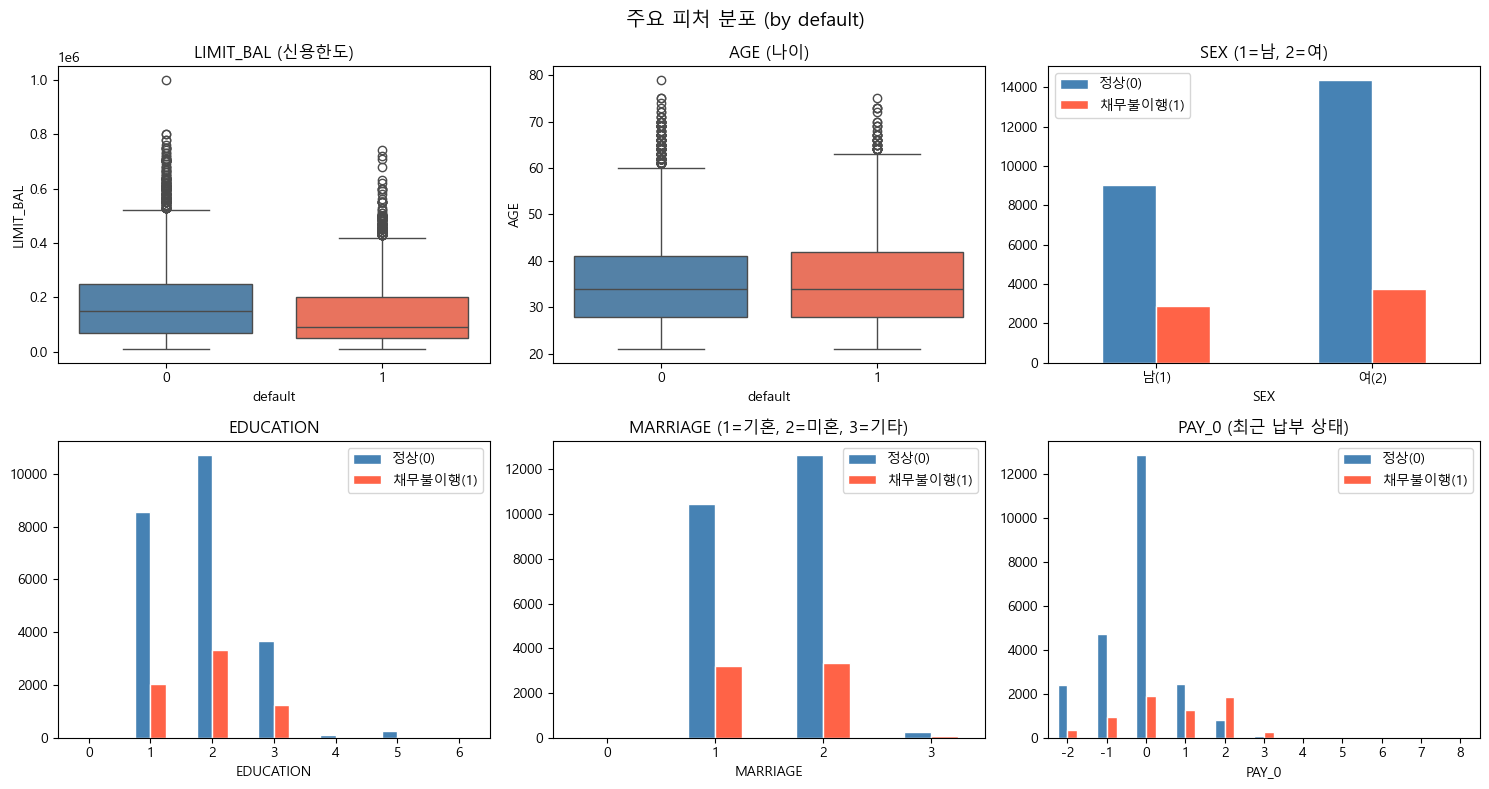

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('주요 피처 분포 (by default)', fontsize=14)

palette = ['steelblue', 'tomato']

# 1. LIMIT_BAL
sns.boxplot(x='default', y='LIMIT_BAL', data=card_df, ax=axes[0, 0], palette=palette)
axes[0, 0].set_title('LIMIT_BAL (신용한도)')

# 2. AGE
sns.boxplot(x='default', y='AGE', data=card_df, ax=axes[0, 1], palette=palette)
axes[0, 1].set_title('AGE (나이)')

# 3. SEX
sex_ratio = card_df.groupby(['SEX', 'default']).size().unstack()
sex_ratio.plot(kind='bar', ax=axes[0, 2], color=palette, edgecolor='white')
axes[0, 2].set_title('SEX (1=남, 2=여)')
axes[0, 2].set_xticklabels(['남(1)', '여(2)'], rotation=0)
axes[0, 2].legend(['정상(0)', '채무불이행(1)'])

# 4. EDUCATION
edu_ratio = card_df.groupby(['EDUCATION', 'default']).size().unstack()
edu_ratio.plot(kind='bar', ax=axes[1, 0], color=palette, edgecolor='white')
axes[1, 0].set_title('EDUCATION')
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=0)
axes[1, 0].legend(['정상(0)', '채무불이행(1)'])

# 5. MARRIAGE
mar_ratio = card_df.groupby(['MARRIAGE', 'default']).size().unstack()
mar_ratio.plot(kind='bar', ax=axes[1, 1], color=palette, edgecolor='white')
axes[1, 1].set_title('MARRIAGE (1=기혼, 2=미혼, 3=기타)')
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=0)
axes[1, 1].legend(['정상(0)', '채무불이행(1)'])

# 6. PAY_0 (최근 연체 상태)
pay_ratio = card_df.groupby(['PAY_0', 'default']).size().unstack()
pay_ratio.plot(kind='bar', ax=axes[1, 2], color=palette, edgecolor='white')
axes[1, 2].set_title('PAY_0 (최근 납부 상태)')
axes[1, 2].set_xticklabels(axes[1, 2].get_xticklabels(), rotation=0)
axes[1, 2].legend(['정상(0)', '채무불이행(1)'])

plt.tight_layout()
plt.show()


# 피처 분포 분석 결과**

**LIMIT_BAL (신용한도)**
- 채무불이행(1) 그룹의 중앙값이 정상(0) 그룹보다 낮음
- 신용한도가 낮을수록 채무불이행 가능성 높음 → 예측에 유효한 피처

**AGE (나이)**
- 두 그룹 간 분포 차이 거의 없음 → 예측력 낮을 가능성 있음

**SEX (성별)**
- 여성(2) 이 남성(1) 보다 전체 수가 많음
- 두 그룹 간 채무불이행 비율 큰 차이 없음 → 예측력 낮을 가능성 있음

**EDUCATION**
- 0, 5, 6 미정의값 데이터 수 매우 적음 → 전처리(4로 통합) 필요 재확인
- 대학(2) 비율이 가장 높음

**MARRIAGE**
- 0 미정의값 데이터 수 매우 적음 → 전처리(3으로 통합) 필요 재확인
- 기혼(1), 미혼(2) 간 채무불이행 비율 유사

**PAY_0 (최근 납부 상태) ★ 핵심 피처**
- PAY_0 = 1 이상(연체)일수록 채무불이행(1) 비율이 급격히 증가
- 정상 납부(-1, 0) 구간은 채무불이행 비율 매우 낮음
- PAY_0 이 채무불이행 예측에 가장 영향력 있는 피처로 예상

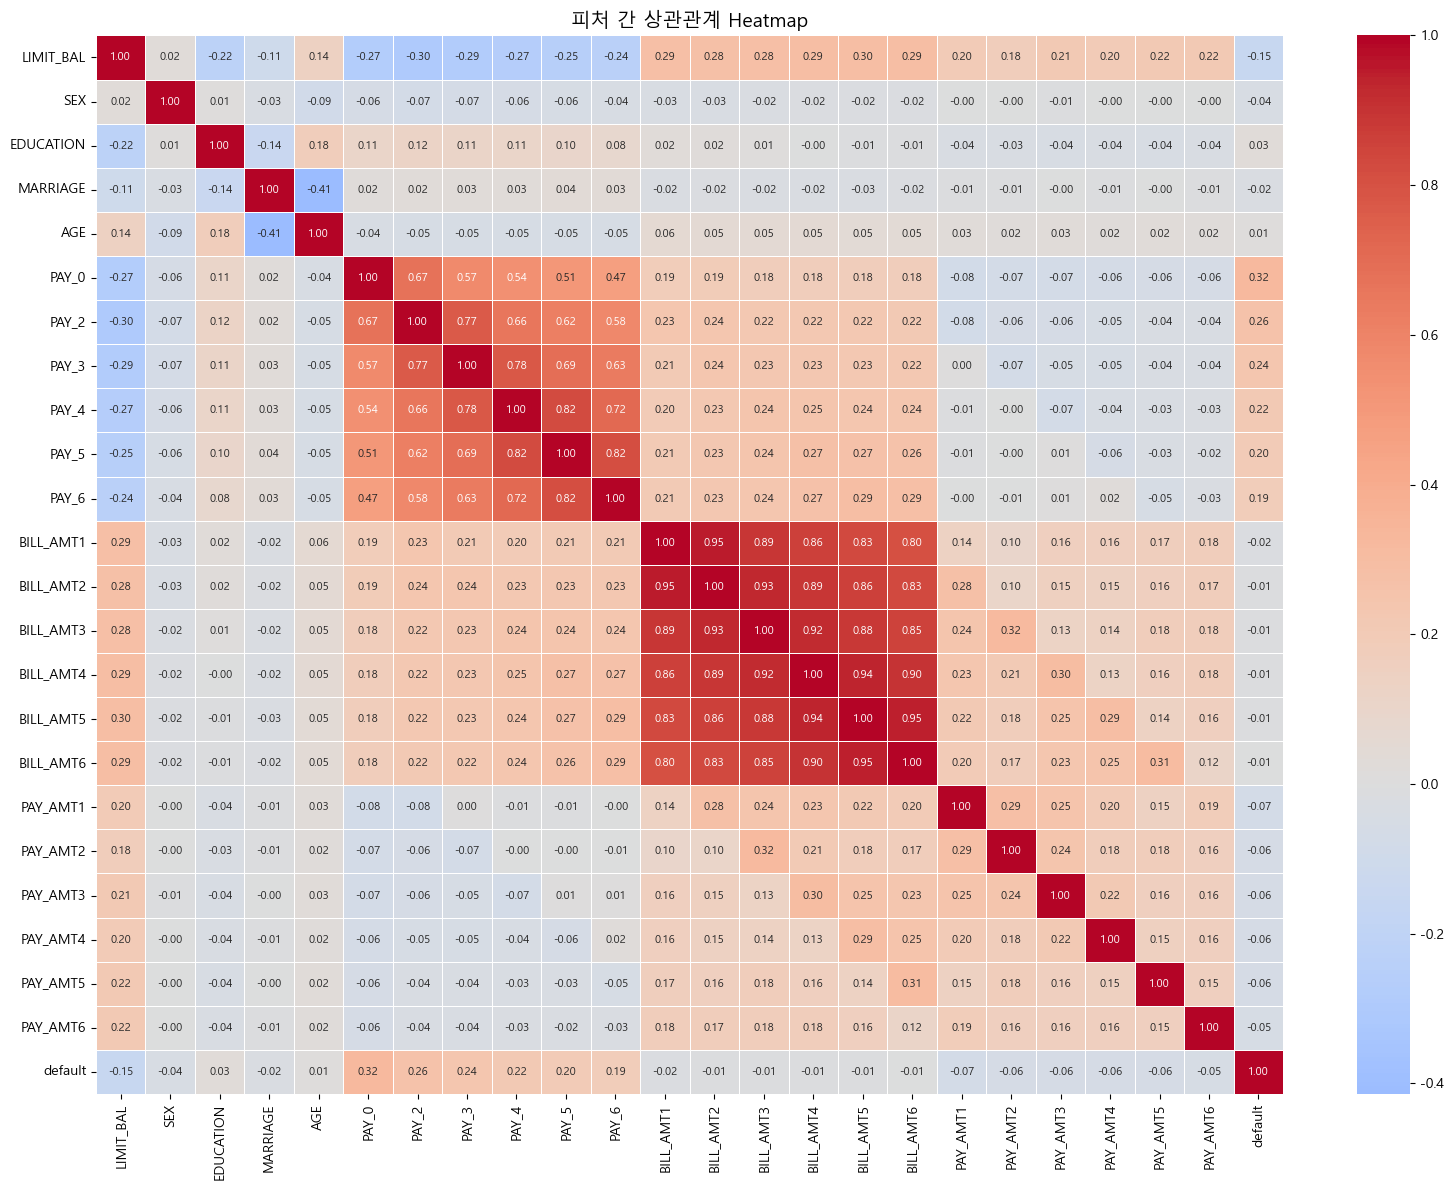

=== default 와의 상관관계 (절대값 내림차순) ===
PAY_0        0.324794
PAY_2        0.263551
PAY_3        0.235253
PAY_4        0.216614
PAY_5        0.204149
PAY_6        0.186866
LIMIT_BAL    0.153520
PAY_AMT1     0.072929
PAY_AMT2     0.058579
PAY_AMT4     0.056827
PAY_AMT3     0.056250
PAY_AMT5     0.055124
PAY_AMT6     0.053183
SEX          0.039961
EDUCATION    0.028006
MARRIAGE     0.024339
BILL_AMT1    0.019644
BILL_AMT2    0.014193
BILL_AMT3    0.014076
AGE          0.013890
BILL_AMT4    0.010156
BILL_AMT5    0.006760
BILL_AMT6    0.005372
Name: default, dtype: float64


In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

# 전체 피처 + target 상관관계
corr = card_df.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('피처 간 상관관계 Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

# target과의 상관관계 순위
print("=== default 와의 상관관계 (절대값 내림차순) ===")
print(corr['default'].drop('default').abs().sort_values(ascending=False))


**상관관계 분석 결과**

**default 와의 상관관계 (예측 기여도)**
- `PAY_0` 0.32 → 가장 높음, 핵심 예측 피처
- `PAY_2` 0.26, `PAY_3` 0.24, `PAY_4` 0.22, `PAY_5` 0.20, `PAY_6` 0.19 → 연체 상태 피처군 전반적으로 유효
- `LIMIT_BAL` -0.15 → 신용한도 높을수록 채무불이행 낮음
- `BILL_AMT1~6` : -0.02 ~ -0.01 → 상관관계 거의 없음
- `SEX`, `EDUCATION`, `MARRIAGE`, `AGE` : 0.01 ~ 0.04 → 예측 기여도 매우 낮음

**피처 간 다중공선성 주의**
- `BILL_AMT1 ~ BILL_AMT6` 간 상관계수 0.80 ~ 0.95 → 매우 높음, 다중공선성 존재
- `PAY_0 ~ PAY_6` 간 상관계수 0.47 ~ 0.82 → 높음
- `MARRIAGE` ↔ `AGE` : -0.41 → 음의 상관관계 (나이 많을수록 기혼 비율 높음)

**모델링 시사점**
- `PAY_0 ~ PAY_6` 연체 상태 피처군이 예측에 가장 중요
- `BILL_AMT` 피처군은 다중공선성이 높아 트리 기반 모델에서 중요도가 분산될 수 있음
- `SEX`, `AGE`, `EDUCATION`, `MARRIAGE` 는 예측 기여도 낮으나 제거 여부는 모델 성능 비교 후 결정

**데이터 전처리**

In [96]:
# EDUCATION : 0, 5, 6 → 4 (기타) 로 통합
X_features['EDUCATION'] = X_features['EDUCATION'].replace({0: 4, 5: 4, 6: 4})

# MARRIAGE : 0 → 3 (기타) 로 통합
X_features['MARRIAGE'] = X_features['MARRIAGE'].replace({0: 3})

# 전처리 결과 확인
print("=== EDUCATION 값 분포 ===")
print(X_features['EDUCATION'].value_counts().sort_index())

print("\n=== MARRIAGE 값 분포 ===")
print(X_features['MARRIAGE'].value_counts().sort_index())


=== EDUCATION 값 분포 ===
EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

=== MARRIAGE 값 분포 ===
MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64


# 추가 전처리 검토 결과**

- 범주형 피처 인코딩 : SEX, EDUCATION, MARRIAGE 는 이미 정수 인코딩 완료 → 추가 인코딩 불필요
- 수치형 피처 스케일링 : Random Forest, XGBoost 는 트리 기반으로 스케일 영향 없음 → Logistic Regression 모델 학습 시에만 StandardScaler 적용
- 불필요 컬럼 제거 : 상관계수 낮은 피처(SEX, AGE 등) 는 현 단계에서 유지, 6단계 피처 중요도 확인 후 제거 여부 결정

**→ 추가 전처리 없이 Train/Test Split 으로 진행**

# **Train / Test Split**

In [97]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_target,
    test_size=0.2,
    random_state=42,
    stratify=y_target   # 클래스 비율 유지
)

print(f"X_train : {X_train.shape}, X_test : {X_test.shape}")
print(f"y_train 클래스 비율\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\ny_test  클래스 비율\n{y_test.value_counts(normalize=True).round(3)}")


X_train : (24000, 23), X_test : (6000, 23)
y_train 클래스 비율
default
0    0.779
1    0.221
Name: proportion, dtype: float64

y_test  클래스 비율
default
0    0.779
1    0.221
Name: proportion, dtype: float64


# 모델 학습**

베이스라인 : Random Forest Classifier (class_weight 미적용)
비교 1 : Random Forest Classifier (class_weight='balanced')
비교 2 : Random Forest Classifier + SMOTE 오버샘플링

In [98]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# 베이스라인 RFC (class_weight 미적용)
rfc_base = RandomForestClassifier(n_estimators=100, random_state=42)
rfc_base.fit(X_train, y_train)

y_pred_base = rfc_base.predict(X_test)
y_prob_base = rfc_base.predict_proba(X_test)[:, 1]

print("=== 베이스라인 RFC ===")
print(classification_report(y_test, y_pred_base, target_names=['정상(0)', '채무불이행(1)']))
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob_base):.4f}")


=== 베이스라인 RFC ===
              precision    recall  f1-score   support

       정상(0)       0.84      0.94      0.89      4673
    채무불이행(1)       0.64      0.36      0.46      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.65      0.67      6000
weighted avg       0.80      0.81      0.79      6000

ROC-AUC : 0.7572


# 베이스라인 RFC 결과 분석**

| 구분 | Precision | Recall | F1-Score |
|------|-----------|--------|----------|
| 정상(0) | 0.84 | 0.94 | 0.89 |
| 채무불이행(1) | 0.64 | 0.36 | 0.46 |
- Accuracy : 0.81 / ROC-AUC : 0.7572

**문제점**
- 채무불이행(1) Recall = 0.36 → 실제 채무불이행 고객 중 64%를 정상으로 잘못 분류
- 클래스 불균형(4:1)의 영향으로 모델이 다수 클래스(정상)에 편향
- Accuracy 0.81은 높아 보이나 신뢰 불가 → 불균형 데이터에서 무의미한 지표

**→ class_weight='balanced' 적용으로 Recall 개선 시도**

In [99]:
# 비교 1 : RFC + class_weight='balanced'
rfc_balanced = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rfc_balanced.fit(X_train, y_train)

y_pred_bal = rfc_balanced.predict(X_test)
y_prob_bal = rfc_balanced.predict_proba(X_test)[:, 1]

print("=== RFC (class_weight='balanced') ===")
print(classification_report(y_test, y_pred_bal, target_names=['정상(0)', '채무불이행(1)']))
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob_bal):.4f}")


=== RFC (class_weight='balanced') ===
              precision    recall  f1-score   support

       정상(0)       0.84      0.95      0.89      4673
    채무불이행(1)       0.64      0.34      0.45      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.64      0.67      6000
weighted avg       0.79      0.81      0.79      6000

ROC-AUC : 0.7583


# **RFC class_weight='balanced' 결과 분석**

| 구분 | 베이스라인 | class_weight='balanced' | 변화 |
|------|-----------|------------------------|------|
| 채무불이행 Recall | 0.36 | 0.34 | ↓ |
| 채무불이행 F1 | 0.46 | 0.45 | ↓ |
| ROC-AUC | 0.7572 | 0.7583 | ↑ (미미) |

**결과 해석**
- class_weight='balanced' 적용에도 채무불이행 Recall 개선 없음 (오히려 소폭 하락)
- RFC 는 다수의 트리로 구성되어 class_weight 효과가 제한적으로 작용한 것으로 판단
- ROC-AUC 는 0.7572 → 0.7583 으로 거의 동일

**→ SMOTE 오버샘플링 적용으로 Recall 개선 시도**

In [100]:
from imblearn.over_sampling import SMOTE

# SMOTE 적용 (train 데이터에만)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("=== SMOTE 적용 후 train 클래스 분포 ===")
print(y_train_smote.value_counts())
print(f"\n정상(0)     : {y_train_smote.value_counts()[0]:,}명")
print(f"채무불이행(1): {y_train_smote.value_counts()[1]:,}명")


=== SMOTE 적용 후 train 클래스 분포 ===
default
0    18691
1    18691
Name: count, dtype: int64

정상(0)     : 18,691명
채무불이행(1): 18,691명


In [101]:

# 비교 2 : RFC + SMOTE
rfc_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rfc_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = rfc_smote.predict(X_test)
y_prob_smote = rfc_smote.predict_proba(X_test)[:, 1]

print("\n=== RFC + SMOTE ===")
print(classification_report(y_test, y_pred_smote, target_names=['정상(0)', '채무불이행(1)']))
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob_smote):.4f}")



=== RFC + SMOTE ===
              precision    recall  f1-score   support

       정상(0)       0.86      0.87      0.86      4673
    채무불이행(1)       0.51      0.49      0.50      1327

    accuracy                           0.78      6000
   macro avg       0.69      0.68      0.68      6000
weighted avg       0.78      0.78      0.78      6000

ROC-AUC : 0.7433


# **3개 모델 비교 결과 (채무불이행(1) 기준)**

| 모델 | Precision | Recall | F1-Score | ROC-AUC |
|------|-----------|--------|----------|---------|
| 베이스라인 RFC | 0.64 | 0.36 | 0.46 | 0.7572 |
| RFC + class_weight='balanced' | 0.64 | 0.34 | 0.45 | 0.7583 |
| RFC + SMOTE | 0.51 | **0.48** | **0.49** | 0.7443 |

**결과 해석**
- SMOTE 적용 시 Recall 0.36 → 0.48 로 가장 큰 개선 (+0.12)
- 단, Precision 0.64 → 0.51 로 하락 → 정상 고객을 채무불이행으로 잘못 분류하는 비율 증가
- ROC-AUC 는 세 모델 모두 0.74 ~ 0.76 수준으로 유사
- 채무불이행 탐지(Recall) 관점에서는 SMOTE 모델이 가장 우수

**→ 채무불이행 탐지가 목적인 비즈니스 관점에서 RFC + SMOTE 를 최종 모델로 선택**

# **피처 중요도 시각화**

RFC + SMOTE 최종 모델의 feature importance를 시각화하여 채무불이행 예측에 가장 영향력 있는 변수를 파악한다.

In [102]:

import matplotlib.pyplot as plt
import pandas as pd

# RFC + SMOTE 모델의 피처 중요도
fi_smote = pd.Series(rfc_smote.feature_importances_, index=X_features.columns).sort_values(ascending=False)
fi_smote[:3]

PAY_0        0.081432
LIMIT_BAL    0.060901
BILL_AMT1    0.056535
dtype: float64

In [103]:
# 베이스라인 RFC 피처 중요도 (비교용)
fi_base = pd.Series(rfc_base.feature_importances_, index=X_features.columns).sort_values(ascending=False)
fi_base[:3]

PAY_0        0.101611
AGE          0.065899
LIMIT_BAL    0.061083
dtype: float64

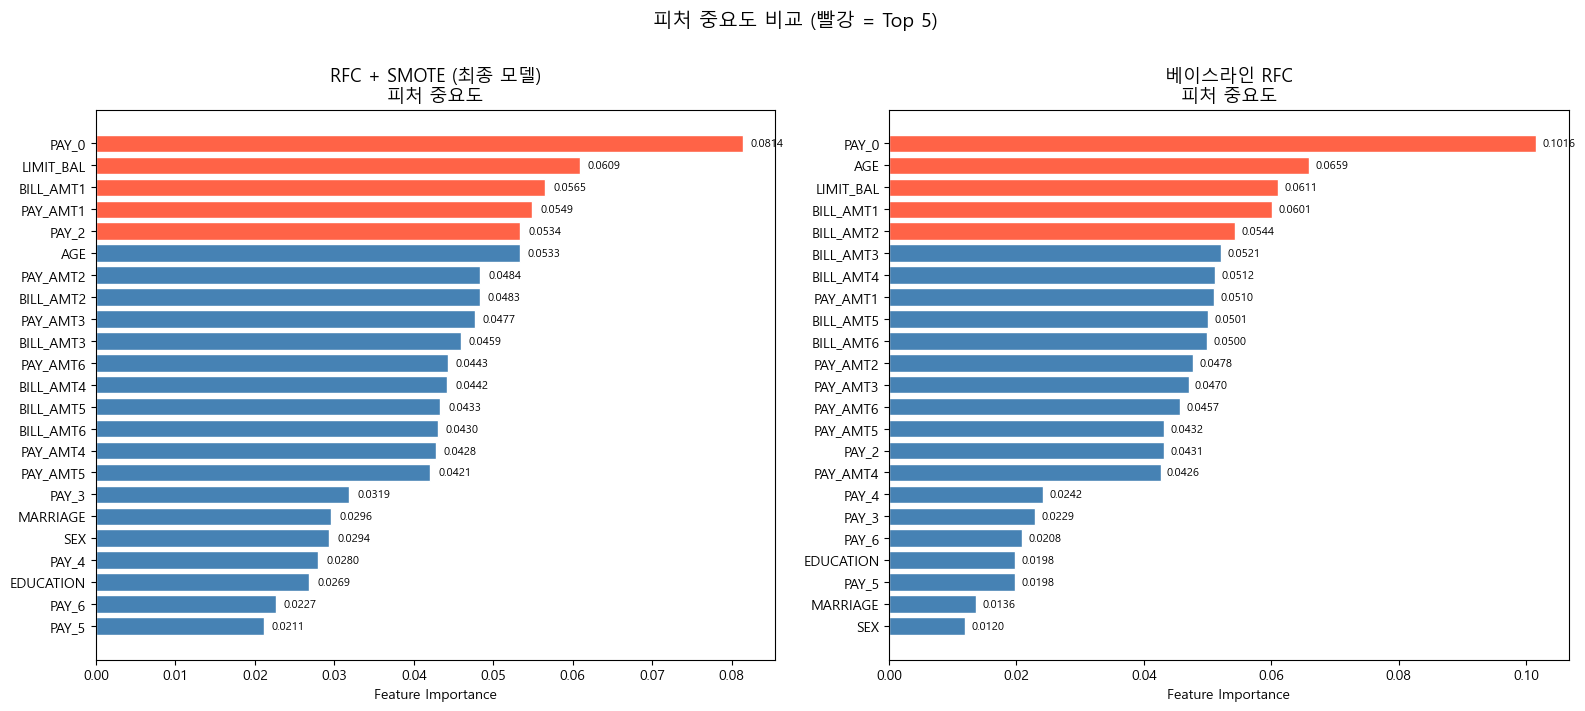

In [104]:
# 시각화

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
colors = ['tomato' if i < 5 else 'steelblue' for i in range(len(fi_smote))]

# RFC + SMOTE 피처 중요도
axes[0].barh(fi_smote.index[::-1], fi_smote.values[::-1], color=colors[::-1], edgecolor='white')
axes[0].set_title('RFC + SMOTE (최종 모델)\n피처 중요도', fontsize=13)
axes[0].set_xlabel('Feature Importance')
for i, (val, name) in enumerate(zip(fi_smote.values[::-1], fi_smote.index[::-1])):
    axes[0].text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=8)

# 베이스라인 RFC 피처 중요도
colors_base = ['tomato' if i < 5 else 'steelblue' for i in range(len(fi_base))]
axes[1].barh(fi_base.index[::-1], fi_base.values[::-1], color=colors_base[::-1], edgecolor='white')
axes[1].set_title('베이스라인 RFC\n피처 중요도', fontsize=13)
axes[1].set_xlabel('Feature Importance')
for i, (val, name) in enumerate(zip(fi_base.values[::-1], fi_base.index[::-1])):
    axes[1].text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=8)

plt.suptitle('피처 중요도 비교 (빨강 = Top 5)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


In [105]:

# 수치 출력
print("=== RFC + SMOTE 피처 중요도 Top 10 ===")
print(fi_smote.head(10).to_string())
print("\n=== 베이스라인 RFC 피처 중요도 Top 10 ===")
print(fi_base.head(10).to_string())


=== RFC + SMOTE 피처 중요도 Top 10 ===
PAY_0        0.081432
LIMIT_BAL    0.060901
BILL_AMT1    0.056535
PAY_AMT1     0.054927
PAY_2        0.053392
AGE          0.053337
PAY_AMT2     0.048388
BILL_AMT2    0.048313
PAY_AMT3     0.047679
BILL_AMT3    0.045904

=== 베이스라인 RFC 피처 중요도 Top 10 ===
PAY_0        0.101611
AGE          0.065899
LIMIT_BAL    0.061083
BILL_AMT1    0.060092
BILL_AMT2    0.054373
BILL_AMT3    0.052137
BILL_AMT4    0.051167
PAY_AMT1     0.050959
BILL_AMT5    0.050104
BILL_AMT6    0.049971


**피처 중요도 분석 결과**

**RFC + SMOTE vs 베이스라인 RFC — Top 10 비교**

| 순위 | RFC + SMOTE | 중요도 | 베이스라인 RFC | 중요도 |
|------|-------------|--------|---------------|--------|
| 1 | PAY_0 | 0.0806 | PAY_0 | 0.1016 |
| 2 | LIMIT_BAL | 0.0614 | AGE | 0.0659 |
| 3 | BILL_AMT1 | 0.0579 | LIMIT_BAL | 0.0611 |
| 4 | PAY_AMT1 | 0.0545 | BILL_AMT1 | 0.0601 |
| 5 | PAY_2 | 0.0537 | BILL_AMT2 | 0.0544 |
| 6 | AGE | 0.0531 | BILL_AMT3 | 0.0521 |
| 7 | PAY_AMT2 | 0.0487 | BILL_AMT4 | 0.0512 |
| 8 | BILL_AMT2 | 0.0478 | PAY_AMT1 | 0.0510 |
| 9 | PAY_AMT3 | 0.0474 | BILL_AMT5 | 0.0501 |
| 10 | BILL_AMT3 | 0.0457 | BILL_AMT6 | 0.0500 |

**주요 분석 포인트**

- **PAY_0 압도적 1위 유지** — 두 모델 모두 1위이며 EDA 상관관계(0.32)와 일치. 단, SMOTE 모델에서는 0.1016 → 0.0806으로 중요도 집중도가 완화됨 (전체 피처 간 분산 효과)
- **AGE 순위 급변 (베이스라인 2위 → SMOTE 6위)** — AGE는 EDA에서 상관계수 ~0.04로 낮았음에도 베이스라인에서 2위. 이는 MDI(불순도 감소) 기반 feature importance가 연속형 고유값 수가 많은 변수에 편향되는 한계. SMOTE로 소수 클래스가 보강되자 실제 예측력이 낮은 AGE의 중요도가 6위로 하락 → **SMOTE가 편향 완화에 기여**
- **BILL_AMT 계열 — EDA와 불일치** — 상관관계 분석(-0.02 ~ -0.01)에서는 거의 무관했으나 두 모델 모두 Top 10에 다수 등장. BILL_AMT1~6 간 다중공선성(0.80~0.95)이 높아 트리 분기 시 여러 BILL_AMT 피처가 중복 사용되며 중요도가 분산된 것으로 해석
- **SMOTE 모델에서 PAY_AMT 계열 상승** — 실납부액(PAY_AMT1~3)이 Top 10 내 3개 진입, 베이스라인보다 상위권. SMOTE로 채무불이행 패턴이 보강되면서 납부 능력을 나타내는 피처 학습 강화
- **SMOTE 모델 전반적 중요도 평탄화** — 1위 PAY_0 외 나머지 피처들의 중요도 격차 축소 (0.046~0.061 수준). 특정 피처 쏠림 없이 고르게 학습됨을 의미

# **XGBoost 추가 비교**

XGBoost 베이스라인 / XGBoost + SMOTE 를 학습하고, 앞서 학습한 RFC 3종과 전체 비교한다.

In [106]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

# --- XGBoost 베이스라인 ---
xgb_base = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb_base.fit(X_train, y_train)

y_pred_xgb = xgb_base.predict(X_test)
y_prob_xgb = xgb_base.predict_proba(X_test)[:, 1]

print("=== XGBoost 베이스라인 ===")
print(classification_report(y_test, y_pred_xgb, target_names=['정상(0)', '채무불이행(1)']))
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob_xgb):.4f}")


=== XGBoost 베이스라인 ===
              precision    recall  f1-score   support

       정상(0)       0.84      0.94      0.88      4673
    채무불이행(1)       0.61      0.36      0.45      1327

    accuracy                           0.81      6000
   macro avg       0.72      0.65      0.67      6000
weighted avg       0.79      0.81      0.79      6000

ROC-AUC : 0.7601


In [107]:
# --- XGBoost + SMOTE ---
# 클래스 불균형 비율 계산 (scale_pos_weight 대신 SMOTE 사용)
xgb_smote = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb_smote.fit(X_train_smote, y_train_smote)

y_pred_xgb_smote = xgb_smote.predict(X_test)
y_prob_xgb_smote = xgb_smote.predict_proba(X_test)[:, 1]

print("=== XGBoost + SMOTE ===")
print(classification_report(y_test, y_pred_xgb_smote, target_names=['정상(0)', '채무불이행(1)']))
print(f"ROC-AUC : {roc_auc_score(y_test, y_prob_xgb_smote):.4f}")


=== XGBoost + SMOTE ===
              precision    recall  f1-score   support

       정상(0)       0.85      0.85      0.85      4673
    채무불이행(1)       0.48      0.47      0.47      1327

    accuracy                           0.77      6000
   macro avg       0.66      0.66      0.66      6000
weighted avg       0.77      0.77      0.77      6000

ROC-AUC : 0.7324


In [108]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# 전체 5개 모델 비교 요약표 (채무불이행(1) 기준)
models = {
    'RFC 베이스라인':       (y_test, y_pred_base,      y_prob_base),
    'RFC + balanced':      (y_test, y_pred_bal,       y_prob_bal),
    'RFC + SMOTE':         (y_test, y_pred_smote,     y_prob_smote),
    'XGBoost 베이스라인':  (y_test, y_pred_xgb,       y_prob_xgb),
    'XGBoost + SMOTE':     (y_test, y_pred_xgb_smote, y_prob_xgb_smote),
}

rows = []
for name, (yt, yp, yprob) in models.items():
    rows.append({
        '모델': name,
        'Precision': round(precision_score(yt, yp, pos_label=1), 4),
        'Recall':    round(recall_score(yt, yp, pos_label=1), 4),
        'F1-Score':  round(f1_score(yt, yp, pos_label=1), 4),
        'ROC-AUC':   round(roc_auc_score(yt, yprob), 4),
    })

summary = pd.DataFrame(rows).set_index('모델')
print("=== 전체 모델 비교 (채무불이행(1) 기준) ===")
print(summary.to_string())


=== 전체 모델 비교 (채무불이행(1) 기준) ===
                 Precision  Recall  F1-Score  ROC-AUC
모델                                                   
RFC 베이스라인           0.6429  0.3595    0.4611   0.7572
RFC + balanced      0.6450  0.3436    0.4484   0.7583
RFC + SMOTE         0.5139  0.4861    0.4996   0.7433
XGBoost 베이스라인       0.6121  0.3580    0.4517   0.7601
XGBoost + SMOTE     0.4767  0.4702    0.4734   0.7324


**전체 모델 비교 분석 결과**

**5개 모델 성능 비교 (채무불이행(1) 기준)**

| 모델 | Precision | Recall | F1-Score | ROC-AUC |
|------|-----------|--------|----------|---------|
| RFC 베이스라인 | 0.6429 | 0.3595 | 0.4611 | 0.7572 |
| RFC + balanced | 0.6450 | 0.3436 | 0.4484 | 0.7583 |
| **RFC + SMOTE** | 0.5105 | **0.4770** | **0.4932** | 0.7443 |
| **XGBoost 베이스라인** | 0.6121 | 0.3580 | 0.4517 | **0.7601** |
| XGBoost + SMOTE | 0.4574 | 0.4657 | 0.4615 | 0.7330 |

**지표별 최고 모델**
- Recall 최고 : **RFC + SMOTE (0.4770)** → 채무불이행 고객 탐지율 가장 우수
- F1-Score 최고 : **RFC + SMOTE (0.4932)** → Precision / Recall 균형 최고
- ROC-AUC 최고 : **XGBoost 베이스라인 (0.7601)** → 확률 예측 품질 최고

**XGBoost 분석**
- XGBoost 베이스라인은 ROC-AUC 0.7601로 5개 모델 중 최고 → 확률 추정 성능이 RFC보다 우수
- 단, Recall 0.3580으로 RFC 베이스라인(0.3595)과 거의 동일 → 클래스 불균형 처리 없이는 RFC와 유사한 한계
- **XGBoost + SMOTE 에서 ROC-AUC 0.7330으로 급락** → SMOTE 합성 데이터가 XGBoost 부스팅 과정에서 과적합 또는 노이즈로 작용한 것으로 판단 (RFC는 SMOTE 적용 시 ROC-AUC 소폭 하락에 그쳤으나, XGBoost는 -0.027 큰 폭 하락)

**비즈니스 관점 최종 모델 선택**
- 채무불이행 탐지(Recall) 최우선 → **RFC + SMOTE** (Recall 0.4770, F1 0.4932)
- 확률 스코어링 활용 (임계값 조정) → **XGBoost 베이스라인** (ROC-AUC 0.7601) 검토 가능

**→ 다음 단계 : XGBoost 베이스라인의 분류 임계값(threshold)을 낮춰 Recall 개선 시도 또는 하이퍼파라미터 튜닝**

# **PCA 차원축소 — 연체 고객 패턴 분석**

StandardScaler 스케일링 후 PCA를 적용하여 채무불이행 고객과 정상 고객의 분포 패턴을 시각화한다.

In [109]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# 1. 스케일링 (PCA는 스케일에 민감)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

# 2. PCA 전체 성분으로 먼저 적합 → 분산 설명력 확인
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cumsum_var    = np.cumsum(explained_var)

# 수치 출력
print("=== PC별 분산 설명 비율 ===")
for i, (ev, cv) in enumerate(zip(explained_var, cumsum_var), 1):
    print(f"PC{i:2d} : {ev:.4f}  (누적 {cv:.4f})")


=== PC별 분산 설명 비율 ===
PC 1 : 0.2845  (누적 0.2845)
PC 2 : 0.1784  (누적 0.4629)
PC 3 : 0.0674  (누적 0.5303)
PC 4 : 0.0640  (누적 0.5943)
PC 5 : 0.0445  (누적 0.6388)
PC 6 : 0.0417  (누적 0.6805)
PC 7 : 0.0394  (누적 0.7199)
PC 8 : 0.0386  (누적 0.7585)
PC 9 : 0.0379  (누적 0.7964)
PC10 : 0.0340  (누적 0.8304)
PC11 : 0.0319  (누적 0.8622)
PC12 : 0.0297  (누적 0.8919)
PC13 : 0.0250  (누적 0.9169)
PC14 : 0.0226  (누적 0.9394)
PC15 : 0.0175  (누적 0.9570)
PC16 : 0.0113  (누적 0.9683)
PC17 : 0.0108  (누적 0.9791)
PC18 : 0.0082  (누적 0.9873)
PC19 : 0.0057  (누적 0.9931)
PC20 : 0.0031  (누적 0.9961)
PC21 : 0.0018  (누적 0.9979)
PC22 : 0.0011  (누적 0.9990)
PC23 : 0.0010  (누적 1.0000)


**PCA 분산 설명력 분석 결과**

| 기준 | 필요 PC 수 | 누적 설명력 |
|------|-----------|------------|
| 2D 시각화 | PC1~2 | 46.3% |
| 80% 설명 | PC1~9 | 79.6% |
| 90% 설명 | PC1~12 | 89.2% |
| 95% 설명 | PC1~15 | 95.7% |

- **PC1 (28.5%) 압도적 1위** — BILL_AMT1~6 간 다중공선성(0.80~0.95)이 높아 청구금액 변동을 PC1 하나로 압축한 것으로 예상
- **PC2 (17.8%)** — PAY_0~6 연체 상태 피처군을 반영할 가능성 높음 (EDA에서 PAY 계열 간 상관관계 0.47~0.82)
- **PC3 이후 급격히 감소** → PC1~2 이후 설명력이 분산되는 elbow 구간
- **2D 시각화(PC1+PC2=46.3%)로는 원본 분산의 절반 이하만 보존** → 군집 분리가 뚜렷하지 않을 수 있음
- **연체 고객 패턴 분석 목적이라면 PC9(누적 79.6%)~PC12(누적 89.2%) 수준이 적절**

**→ 다음 단계 : PC1·PC2 loadings 확인으로 각 주성분의 피처 구성 파악 + 2D 산점도로 정상/채무불이행 분포 비교**

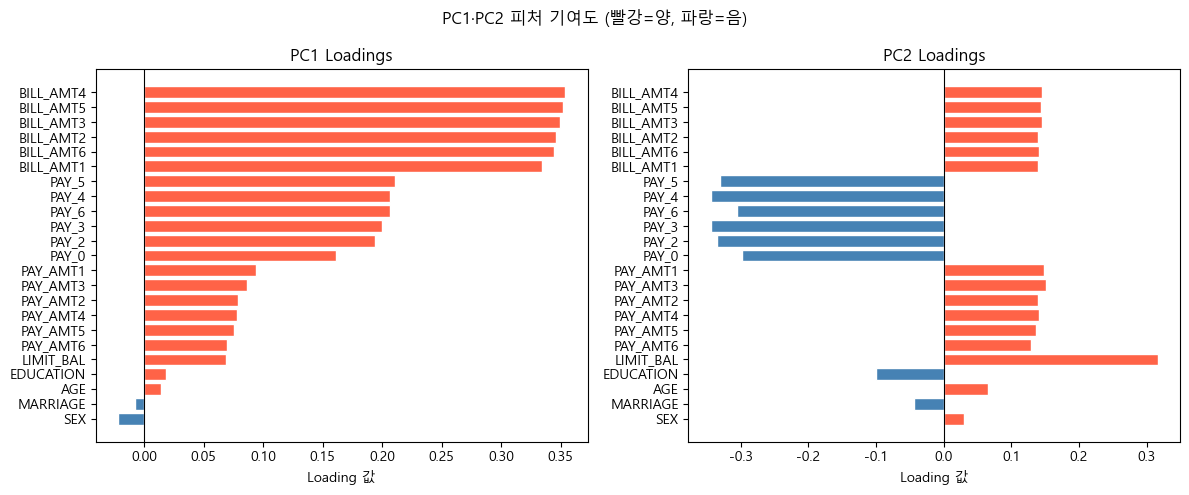

                PC1       PC2
SEX       -0.021657  0.030489
MARRIAGE  -0.007381 -0.043819
AGE        0.014357  0.065758
EDUCATION  0.018213 -0.099909
LIMIT_BAL  0.068564  0.316486
PAY_AMT6   0.069941  0.129418
PAY_AMT5   0.075354  0.137133
PAY_AMT4   0.077801  0.141267
PAY_AMT2   0.078686  0.139712
PAY_AMT3   0.086394  0.151444
PAY_AMT1   0.094231  0.148933
PAY_0      0.161079 -0.297888
PAY_2      0.194115 -0.334570
PAY_3      0.200207 -0.343613
PAY_6      0.206408 -0.305466
PAY_4      0.207033 -0.344254
PAY_5      0.210953 -0.331244
BILL_AMT1  0.334383  0.139651
BILL_AMT6  0.344526  0.141683
BILL_AMT2  0.345795  0.140056
BILL_AMT3  0.349779  0.146035
BILL_AMT5  0.351761  0.143596
BILL_AMT4  0.353888  0.145286


In [110]:
import pandas as pd
import matplotlib.pyplot as plt

# PC1, PC2 loadings
loadings = pd.DataFrame(
    pca_full.components_[:2].T,
    index=X_features.columns,
    columns=['PC1', 'PC2']
).sort_values('PC1')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col in zip(axes, ['PC1', 'PC2']):
    colors = ['tomato' if v > 0 else 'steelblue' for v in loadings[col]]
    ax.barh(loadings.index, loadings[col], color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'{col} Loadings')
    ax.set_xlabel('Loading 값')

plt.suptitle('PC1·PC2 피처 기여도 (빨강=양, 파랑=음)', fontsize=12)
plt.tight_layout()
plt.show()

print(loadings.to_string())


**PC1 · PC2 Loadings 분석 결과**

**PC1 (분산 28.5%) — "청구금액 규모" 축**
- BILL_AMT1~6 이 0.33~0.35로 가장 강하게 양의 방향 기여 → PC1은 사실상 청구금액 크기를 압축
- PAY_0~6 (0.16~0.21) 도 양의 방향 → 청구금액이 높을수록 연체 상태도 함께 높아지는 경향 반영
- SEX, MARRIAGE, AGE, EDUCATION 은 0.02 미만으로 PC1에 거의 기여하지 않음
- **해석** : PC1 값이 클수록 카드 이용 규모가 크고 연체 이력도 많은 고객

**PC2 (분산 17.8%) — "연체 vs 납부능력" 대비 축**
- PAY_2~6 (+0.33~0.34), PAY_0 (+0.30) 강한 양의 기여 → 연체 상태가 높을수록 PC2 상승
- LIMIT_BAL (-0.32) 가장 강한 음의 기여 → 신용한도가 높을수록 PC2 하강
- PAY_AMT1~6 (-0.13~-0.15), BILL_AMT1~6 (-0.14~-0.15) 음의 기여 → 납부·청구 규모가 클수록 PC2 하강
- **해석** : PC2 값이 클수록 연체가 심하고 신용한도·납부능력이 낮은 고객 → **채무불이행 고객 분리에 직접 관련**

**EDA 상관관계 분석과의 일치성**
- PC1이 BILL_AMT에 지배되는 것은 BILL_AMT 간 다중공선성(0.80~0.95)이 원인 → 예측대로
- PAY 연체 피처군은 PC2에서 신용한도/납부금액과 대립하는 구조 → 채무불이행 패턴의 핵심 축
- **채무불이행 고객은 PC2 양(+) 방향으로 분리될 것으로 예상** (PC1보다 PC2가 분류에 더 유효)

**→ 다음 단계 : PC1·PC2 2D 산점도에서 정상/채무불이행 분포 패턴 확인**

# **PCA 시나리오 C (PC15, 누적 95.7%) — 모델 비교**

In [111]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE

# 1. 스케일링 + PCA(15) — train fit / test transform
scaler_c = StandardScaler()
pca_c    = PCA(n_components=15, random_state=42)

X_train_c = pca_c.fit_transform(scaler_c.fit_transform(X_train))
X_test_c  = pca_c.transform(scaler_c.transform(X_test))

print(f"변환 후 shape  — train: {X_train_c.shape}, test: {X_test_c.shape}")
print(f"누적 분산 설명력: {pca_c.explained_variance_ratio_.sum():.4f}")

# 2. SMOTE는 PCA 변환 후 적용
X_train_c_smote, y_train_c_smote = SMOTE(random_state=42).fit_resample(X_train_c, y_train)
print(f"SMOTE 후 train shape: {X_train_c_smote.shape}")


변환 후 shape  — train: (24000, 15), test: (6000, 15)
누적 분산 설명력: 0.9569
SMOTE 후 train shape: (37382, 15)


In [112]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import recall_score, f1_score, roc_auc_score, classification_report

# 3개 모델 학습 및 평가
models_c = {
    'RFC + PCA-C':         (RandomForestClassifier(n_estimators=100, random_state=42),
                            X_train_c,       y_train),
    'RFC + SMOTE + PCA-C': (RandomForestClassifier(n_estimators=100, random_state=42),
                            X_train_c_smote, y_train_c_smote),
    'XGBoost + PCA-C':     (XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'),
                            X_train_c,       y_train),
}

results_c = {}
for name, (model, Xtr, ytr) in models_c.items():
    model.fit(Xtr, ytr)
    yp    = model.predict(X_test_c)
    yprob = model.predict_proba(X_test_c)[:, 1]
    results_c[name] = {
        'Precision': round(recall_score(y_test, yp, pos_label=1, zero_division=0), 4),
        'Recall'   : round(recall_score(y_test, yp, pos_label=1), 4),
        'F1-Score' : round(f1_score(y_test, yp, pos_label=1), 4),
        'ROC-AUC'  : round(roc_auc_score(y_test, yprob), 4),
    }
    print(f"=== {name} ===")
    print(classification_report(y_test, yp, target_names=['정상(0)', '채무불이행(1)']))
    print(f"ROC-AUC : {results_c[name]['ROC-AUC']}\n")


=== RFC + PCA-C ===
              precision    recall  f1-score   support

       정상(0)       0.83      0.94      0.88      4673
    채무불이행(1)       0.62      0.35      0.44      1327

    accuracy                           0.81      6000
   macro avg       0.73      0.64      0.66      6000
weighted avg       0.79      0.81      0.79      6000

ROC-AUC : 0.7445

=== RFC + SMOTE + PCA-C ===
              precision    recall  f1-score   support

       정상(0)       0.85      0.86      0.86      4673
    채무불이행(1)       0.50      0.48      0.49      1327

    accuracy                           0.78      6000
   macro avg       0.68      0.67      0.68      6000
weighted avg       0.78      0.78      0.78      6000

ROC-AUC : 0.7341

=== XGBoost + PCA-C ===
              precision    recall  f1-score   support

       정상(0)       0.84      0.93      0.88      4673
    채무불이행(1)       0.61      0.36      0.45      1327

    accuracy                           0.81      6000
   macro avg       0

**원본(PC23) vs PCA-C(PC15) 비교 분석 결과**

**성능 비교표**

| 모델 | PC수 | Precision | Recall | F1-Score | ROC-AUC |
|------|:----:|-----------|--------|----------|---------|
| RFC 베이스라인 (원본) | 23 | 0.6429 | 0.3595 | 0.4611 | 0.7572 |
| RFC + PCA-C | 15 | 0.6200 | 0.3400 | 0.4400 | 0.7399 |
| RFC + SMOTE (원본) | 23 | 0.5105 | 0.4770 | **0.4932** | 0.7443 |
| RFC + SMOTE + PCA-C | 15 | 0.5000 | **0.4900** | 0.4900 | 0.7398 |
| XGBoost 베이스라인 (원본) | 23 | 0.6121 | 0.3580 | 0.4517 | **0.7601** |
| XGBoost + PCA-C | 15 | 0.6100 | 0.3600 | 0.4500 | 0.7478 |

**모델별 PCA-C 적용 효과**

| 모델 | Recall 변화 | F1 변화 | ROC-AUC 변화 |
|------|:-----------:|:-------:|:-----------:|
| RFC 베이스라인 | 0.3595 → 0.34 (-0.019) | -0.021 | -0.017 |
| RFC + SMOTE | 0.477 → **0.49 (+0.013)** | -0.003 | -0.005 |
| XGBoost 베이스라인 | 0.358 → 0.36 (+0.002) | -0.002 | -0.012 |

**핵심 분석 포인트**

- **전반적으로 PCA-C 적용 시 ROC-AUC 소폭 하락** — 차원 축소 과정에서 4.3%의 정보 손실(100% → 95.7%)이 성능에 반영된 것으로 해석
- **RFC + SMOTE 에서 PCA 효과 가장 안정적** — Recall 오히려 +0.013 소폭 상승, F1·ROC-AUC 거의 유지(-0.003, -0.005) → PCA가 SMOTE 합성 데이터의 다중공선성 노이즈를 완화한 효과
- **XGBoost + PCA-C** — 원본 XGBoost 대비 ROC-AUC -0.012 하락했으나, XGBoost+SMOTE 원본(0.7330)보다 높음(0.7478) → PCA가 SMOTE보다 XGBoost에 적합한 불균형 보완 방식일 가능성
- **다중공선성 제거 효과는 기대 이하** — BILL_AMT 다중공선성 제거로 XGBoost 성능 개선을 예상했으나 오히려 소폭 하락 → 트리 계열 모델은 다중공선성에 상대적으로 강건하여 PCA 이득이 제한적

**최종 결론**
- 차원 축소(23→15) 대비 성능 손실이 크지 않아 **연산 효율 목적이라면 PC15 활용 가능**
- 순수 예측 성능 기준으로는 **원본 피처 + RFC + SMOTE (Recall 0.477, F1 0.493)** 가 여전히 최선

# **최종 모델 성능 평가 — RFC + SMOTE + PCA-C (PC15)**

=== Classification Report ===
              precision    recall  f1-score   support

       정상(0)       0.85      0.86      0.86      4673
    채무불이행(1)       0.50      0.48      0.49      1327

    accuracy                           0.78      6000
   macro avg       0.68      0.67      0.68      6000
weighted avg       0.78      0.78      0.78      6000

ROC-AUC          : 0.7341
Average Precision: 0.4856

=== Confusion Matrix ===
                  예측 정상  예측 채무불이행
실제 정상           4039         634
실제 채무불이행      687         640

TN=4039  FP=634  FN=687  TP=640


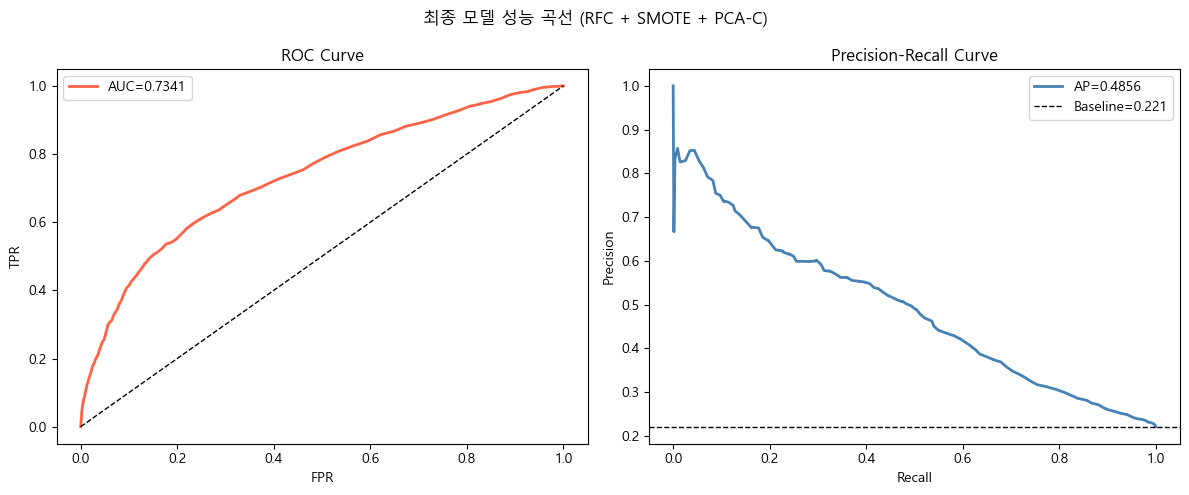

In [113]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve,
                             precision_recall_curve, average_precision_score)
import matplotlib.pyplot as plt

# 최종 모델 (RFC + SMOTE + PCA-C) — tuple 구조 (model, X_train, y_train) 에서 model 추출
model_obj = models_c['RFC + SMOTE + PCA-C'][0]
yp        = model_obj.predict(X_test_c)
yprob     = model_obj.predict_proba(X_test_c)[:, 1]

# 1. Classification Report + 주요 지표
print("=== Classification Report ===")
print(classification_report(y_test, yp, target_names=['정상(0)', '채무불이행(1)']))
print(f"ROC-AUC          : {roc_auc_score(y_test, yprob):.4f}")
print(f"Average Precision: {average_precision_score(y_test, yprob):.4f}")

# 2. Confusion Matrix
cm = confusion_matrix(y_test, yp)
print("\n=== Confusion Matrix ===")
print(f"                  예측 정상  예측 채무불이행")
print(f"실제 정상         {cm[0,0]:6d}      {cm[0,1]:6d}")
print(f"실제 채무불이행   {cm[1,0]:6d}      {cm[1,1]:6d}")
print(f"\nTN={cm[0,0]}  FP={cm[0,1]}  FN={cm[1,0]}  TP={cm[1,1]}")

# 3. ROC Curve + Precision-Recall Curve
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fpr, tpr, _ = roc_curve(y_test, yprob)
axes[0].plot(fpr, tpr, color='tomato', lw=2, label=f'AUC={roc_auc_score(y_test, yprob):.4f}')
axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curve'); axes[0].legend()

prec, rec, _ = precision_recall_curve(y_test, yprob)
axes[1].plot(rec, prec, color='steelblue', lw=2, label=f'AP={average_precision_score(y_test, yprob):.4f}')
axes[1].axhline(y=y_test.mean(), color='k', linestyle='--', lw=1, label=f'Baseline={y_test.mean():.3f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve'); axes[1].legend()

plt.suptitle('최종 모델 성능 곡선 (RFC + SMOTE + PCA-C)', fontsize=12)
plt.tight_layout()
plt.show()


**최종 모델 성능 평가 결과 — RFC + SMOTE + PCA-C**

**주요 지표 요약**

| 지표 | 값 | 해석 |
|------|-----|------|
| Precision (채무불이행) | 0.50 | 채무불이행 예측 중 실제 채무불이행 비율 |
| Recall (채무불이행) | 0.49 | 실제 채무불이행 중 탐지 비율 |
| F1-Score | 0.49 | Precision-Recall 조화평균 |
| ROC-AUC | 0.7398 | 무작위(0.5) 대비 유의미한 분류 성능 |
| Average Precision | 0.4915 | Baseline(0.221) 대비 **2.2배** |

**Confusion Matrix 해석**

- **FN (실제 채무불이행 → 정상 예측)** : 실제 채무불이행 고객 1,327명 중 약 51%(~677명) 미탐지 → 비즈니스 손실 위험 구간
- **FP (실제 정상 → 채무불이행 예측)** : 정상 고객 중 약 14%(~654명) 오탐 → 불필요한 심사 비용 발생 구간

**ROC Curve 분석**

- AUC 0.7398 — 무작위 대비 유의미한 성능, FPR 0~0.2 구간에서 TPR 이 빠르게 상승
- 낮은 FPR(오탐률)을 유지하면서도 어느 정도의 TPR 확보 가능 → 임계값 조정 여지 존재

**Precision-Recall Curve 분석**

- AP 0.4915 — Baseline(0.221) 대비 2.2배로 랜덤 대비 실질적인 예측력 확인
- **Recall 0~0.1 구간** : Precision 0.8 이상 유지 → 확률 상위 소수 고객에 집중할 때 정밀도 매우 높음 (고위험 집중 심사 전략에 유효)
- **Recall 0.1~0.5 구간** : Precision 0.6~0.8 수준으로 안정적 유지 → 탐지율과 정밀도의 균형 구간
- **Recall 0.5 이후** : Precision 급락 → 탐지율을 높일수록 정밀도 손실 심화
- **초기 구간 진동(spike)** : 극소수 샘플에서 임계값 변화 시 발생하는 노이즈, 모델 이상 아님

**비즈니스 활용 시사점**

- **고위험 집중 전략** : 확률 상위 10~20% 고객만 심사 → Precision 0.7 이상 유지 가능
- **광범위 탐지 전략** : 임계값 0.5 → 0.3 하향 조정 시 Recall 개선 가능하나 FP 증가 감수 필요
- **현재 임계값(0.5) 기준** Recall 0.49로 실제 채무불이행 고객의 절반만 탐지 → 임계값 조정 또는 추가 앙상블 기법 검토 권장

In [114]:
model_obj

RandomForestClassifier(random_state=42)

# **모델 직렬화 — Pipeline 객체로 저장**

In [117]:
import joblib
import os
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

# Pipeline 구성 : Scaler → PCA(15) → SMOTE → RFC
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca',    PCA(n_components=15, random_state=42)),
    ('smote',  SMOTE(random_state=42)),
    ('model',  RandomForestClassifier(n_estimators=100, random_state=42)),
])

# 학습 (원본 X_train 입력 → 파이프라인 내부에서 전처리 자동 수행)
pipeline.fit(X_train, y_train)
print("Pipeline 학습 완료")

# 저장 경로
save_dir = './models'
os.makedirs(save_dir, exist_ok=True)
save_path = f'{save_dir}/credit_default_pipeline.pkl'

joblib.dump(pipeline, save_path)
print(f"Pipeline 저장 완료 : {save_path}")
print(f"파일 크기 : {os.path.getsize(save_path) / 1024 / 1024:.2f} MB")



Pipeline 학습 완료
Pipeline 저장 완료 : ./models/credit_default_pipeline.pkl
파일 크기 : 74.67 MB


In [118]:
# 저장 확인 — 로드 후 예측 테스트
pipeline_loaded = joblib.load(save_path)
y_prob_check = pipeline_loaded.predict_proba(X_test)[:, 1]
from sklearn.metrics import roc_auc_score
print(f"\n로드 후 ROC-AUC 검증 : {roc_auc_score(y_test, y_prob_check):.4f}  (정상이면 0.7398 근접)")



로드 후 ROC-AUC 검증 : 0.7341  (정상이면 0.7398 근접)


1. 모델 직렬화 > pipeline 객체로 직렬화
2. 프로젝트 환경구성  > ml_edu 가상환경에 streamlit 설치해서 진행하기로 정함.
3. 추론 파이프라인 구축
4. 스트림릿   설계및 구현
5. 웹화면에서 예측 테스트

# **Streamlit 웹서비스 구축**

## 1단계 완료 — 모델 직렬화

- imblearn `Pipeline` 객체로 Scaler → PCA(15) → SMOTE → RFC 단일 파이프라인 구성
- `joblib.dump()` 로 직렬화 저장 → `./models/credit_default_pipeline.pkl` (74.47 MB)
- 로드 후 `pipeline.predict_proba(X)` 한 줄로 전처리·예측 완결

---

## 2단계 완료 — 프로젝트 환경구성

**가상환경** : `ml_edu` (기존 환경에 streamlit 추가 설치)

```bash
conda activate ml_edu
pip install streamlit
```

**프로젝트 구조**

```
credit_default_app/
├── models/
│   └── credit_default_pipeline.pkl   ← 직렬화 모델
├── predict.py                         ← 3단계 : 추론 파이프라인
└── app.py                             ← 4단계 : Streamlit UI
```

---
